In [1]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#fetch data
df=pd.read_csv(r"E:\Praxis\TERM1\Foml\100 Days\Data\Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [19]:
X= df.drop(['User ID','Gender','Purchased'],axis=1)
y=df['Purchased']

In [22]:
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [23]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [26]:
X_train.shape,y_train.shape

((320, 2), (320,))

In [27]:
X_test.shape,y_test.shape

((80, 2), (80,))

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [30]:
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled

array([[ 0.88928823, -0.65924556],
       [-0.17254846,  0.87392651],
       [-1.04132394, -0.36440478],
       [ 0.98581884,  0.6085698 ],
       [-0.94479333,  0.57908572],
       [ 0.40663519,  0.01888824],
       [ 0.98581884,  2.11225779],
       [ 0.31010458, -0.30543662],
       [ 1.7580637 , -0.27595254],
       [-0.17254846,  2.20071003],
       [ 1.7580637 ,  1.0213469 ],
       [-1.33091576, -1.48479975],
       [ 2.04765553,  0.54960165],
       [ 1.27541066,  1.90586924],
       [-1.13785454,  0.31372902],
       [-0.36560968, -0.77718187],
       [-1.71703819,  0.49063349],
       [-0.5586709 , -1.51428383],
       [ 0.31010458, -0.71821372],
       [ 0.02051275, -0.57079333],
       [ 0.02051275,  0.04837232],
       [-0.07601785, -0.51182517],
       [-0.6552015 , -1.51428383],
       [ 0.02051275,  0.31372902],
       [ 0.31010458,  0.07785639],
       [-0.46214029, -1.13099081],
       [-0.75173211, -1.54376791],
       [-0.26907907, -0.65924556],
       [-1.13785454,

In [32]:
X_test_scaled =scaler.transform(X_test)
X_test_scaled

array([[-0.84826272,  0.40218125],
       [-1.62050759, -1.57325199],
       [-0.07601785, -0.48234109],
       [-0.84826272,  0.16630863],
       [ 1.56500249,  0.01888824],
       [ 0.88928823, -1.45531567],
       [-1.42744637,  0.37269718],
       [-0.94479333, -1.10150673],
       [ 0.21357397, -0.27595254],
       [-0.17254846,  1.66999662],
       [-1.33091576, -1.36686344],
       [-1.52397698, -1.24892713],
       [-0.5586709 ,  1.40463991],
       [ 0.69622701,  0.28424494],
       [-0.26907907, -0.30543662],
       [-0.46214029, -0.77718187],
       [-1.8135688 ,  0.01888824],
       [ 2.14418614, -0.80666595],
       [ 1.46847188,  0.07785639],
       [-1.13785454, -0.77718187],
       [-0.07601785,  0.25476086],
       [ 0.69622701, -0.71821372],
       [-0.75173211, -0.21698439],
       [-0.17254846, -1.07202266],
       [-1.23438515,  0.31372902],
       [ 0.69622701, -1.10150673],
       [ 0.69622701, -1.39634752],
       [ 0.21357397, -0.36440478],
       [ 0.5996964 ,

In [72]:
k=int(np.sqrt(X_train_scaled.shape[0]))

In [64]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=k)

In [65]:
knn.fit(X_train_scaled,y_train)

,n_neighbors,17
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [66]:
y_pred = knn.predict(X_test_scaled)

In [67]:
from sklearn.metrics import accuracy_score,confusion_matrix
accuracy_score(y_pred,y_test)

0.9125

In [68]:
confusion_matrix(y_pred,y_test)

array([[47,  6],
       [ 1, 26]])

In [69]:
# Effect of K on Training Error rate and Validation Error rate

error_train = []
error_test = []

for i in range(1,26):
    knn =KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled,y_train)
    x=confusion_matrix(y_train,knn.predict(X_train_scaled))
    y=confusion_matrix(y_test,knn.predict(X_test_scaled))
    error_train.append((x[0][1]+x[1][0])/x.sum())
    error_test.append((y[0][1]+y[1][0])/x.sum())

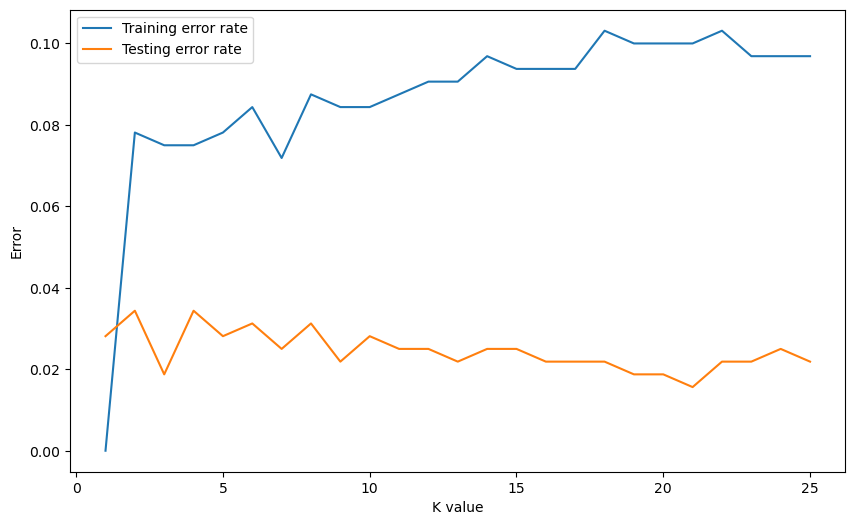

In [70]:
plt.figure(figsize=(10,6))
plt.plot(range(1,26),error_train,label='Training error rate')
plt.plot(range(1,26),error_test,label='Testing error rate')
plt.xlabel('K value')
plt.ylabel('Error')
plt.legend()
plt.show()

# Creating KNN class from Scratch

In [73]:
import operator
from collections import Counter

class KNN:
    def __init__(self,k):
        self.k = k

    def fit(self,X_train,y_train):
        self.X_train = X_train_scaled
        self.y_train = y_train_scaled
        print('Training Done')

    def predict(self,X_test):
        distance ={}
        counter = []

        for i in self.X_train():
            distance[counter]=((X_test[0][0]-i[0])**2 + (X_test[0][0]-i[1])**2)
            counter+=1
        distance=sorted(distance.items(),key=operator.itemgetter(1))

        self.classify(distance = distance[:self.k])

    def classify(self,distance):
        label=[]

        for i in distance:
            label.append(self.y_train[i[0]])

        return Counter(label).most_common()[0][0]

In [79]:
import KNN

ModuleNotFoundError: No module named 'KNN'